# 02 — Exploratory Data Analysis: Booking Trends

**Project:** Uber Data India (2024) Analysis

This notebook explores booking patterns, temporal trends, vehicle performance, and generates visualisations for Review 1.

---

In [1]:
# ============================================================
# CELL 1: Import Libraries & Setup Paths
# ============================================================
import sys
import os

# Add project root to path
notebook_dir = os.path.dirname(os.path.abspath('__file__' if '__file__' in dir() else '.'))
project_root = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.visualization import (
    plot_booking_trends,
    plot_cancellation_analysis,
    plot_revenue_analysis,
    plot_rating_analysis,
    plot_operational_metrics
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries imported!')

✅ Libraries imported!


## Step 1: Load Engineered Data

Load the cleaned and feature-engineered dataset from Notebook 01.

In [2]:
# ============================================================
# CELL 2: Load Data
# ============================================================
try:
    df = pd.read_csv('../data/processed/engineered_uber_data.csv')
    print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'\n📋 Available columns: {list(df.columns)}')
except FileNotFoundError:
    print('❌ File not found: ../data/processed/engineered_uber_data.csv')
    print('   Please run 01_data_cleaning.ipynb first!')
    raise

df.head()

✅ Loaded: 150,000 rows × 36 columns

📋 Available columns: ['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Customer Cancellation', 'Customer Cancellation Reason', 'Driver Cancellation', 'Driver Cancellation Reason', 'Incomplete Ride', 'Incomplete Ride Reason', 'Booking Value', 'Ride Distance', 'Driver Rating', 'Customer Rating', 'Payment Method', 'Booking_DateTime', 'Booking_Hour', 'Booking_Day', 'Booking_Month', 'Booking_Weekday', 'Is_Weekend', 'Time_of_Day', 'Is_Cancelled', 'Cancellation_Type', 'Revenue_per_km', 'High_Value_Ride', 'Wait_Time_Category', 'Distance_Category', 'Avg_Rating', 'Rating_Category']


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Is_Weekend,Time_of_Day,Is_Cancelled,Cancellation_Type,Revenue_per_km,High_Value_Ride,Wait_Time_Category,Distance_Category,Avg_Rating,Rating_Category
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",Ebike,Palam Vihar,Jhilmil,8.3,28.8,...,True,Afternoon,False,NaN,17.453626,False,Moderate (5-10 min),Long (10-25 km),4.4,Good
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,False,Evening,False,NaN,41.361257,False,Quick (<5 min),Medium (3-10 km),4.4,Good
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,False,Morning,False,NaN,46.170839,True,Long (10-20 min),Long (10-25 km),4.9,Excellent
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,False,Evening,False,NaN,12.228101,False,Long (10-20 min),Very Long (>25 km),4.8,Excellent
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,False,Night,False,NaN,15.287285,True,Moderate (5-10 min),Very Long (>25 km),4.2,Good


## Step 2: Booking Trends Over Time

Visualise monthly bookings, hourly demand, and weekday vs. weekend patterns.

💾 Figure saved: ../outputs/figures\booking_trends.png


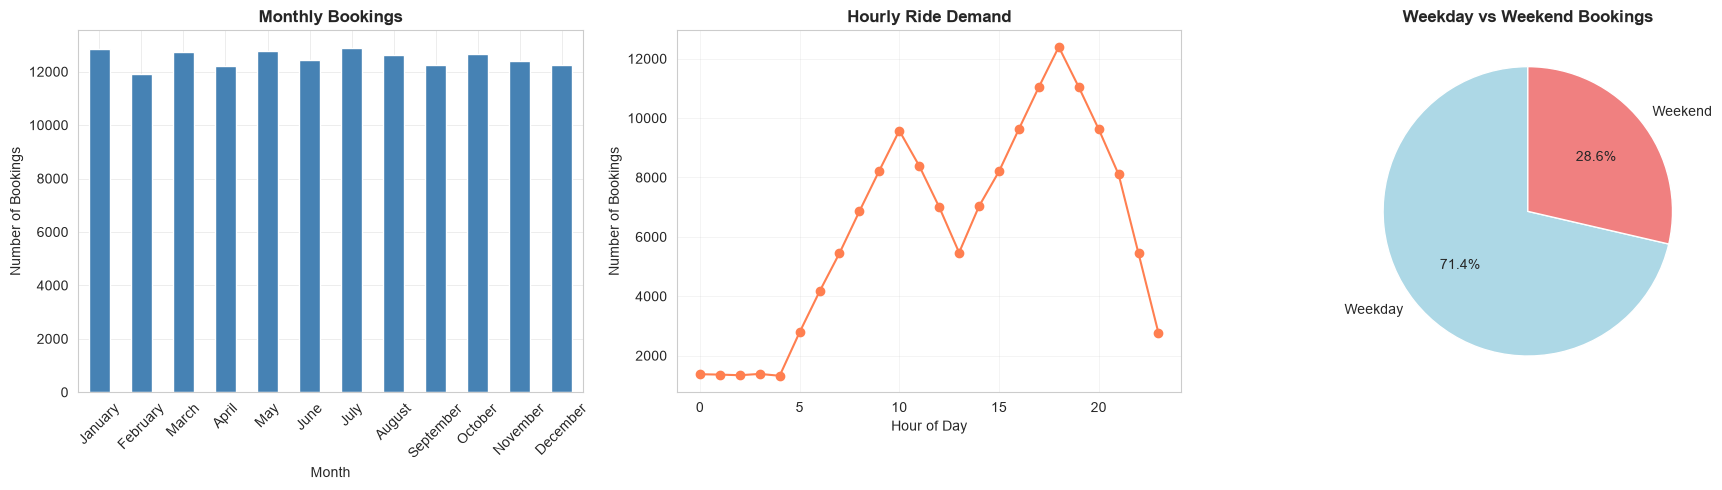

In [3]:
# ============================================================
# CELL 3: Booking Trends Visualisation
# ============================================================
plot_booking_trends(df, save=True)

## Step 3: Cancellation Deep-Dive

Analyse cancellation rates, types, reasons, and vehicle-specific patterns.

💾 Figure saved: ../outputs/figures\cancellation_analysis.png


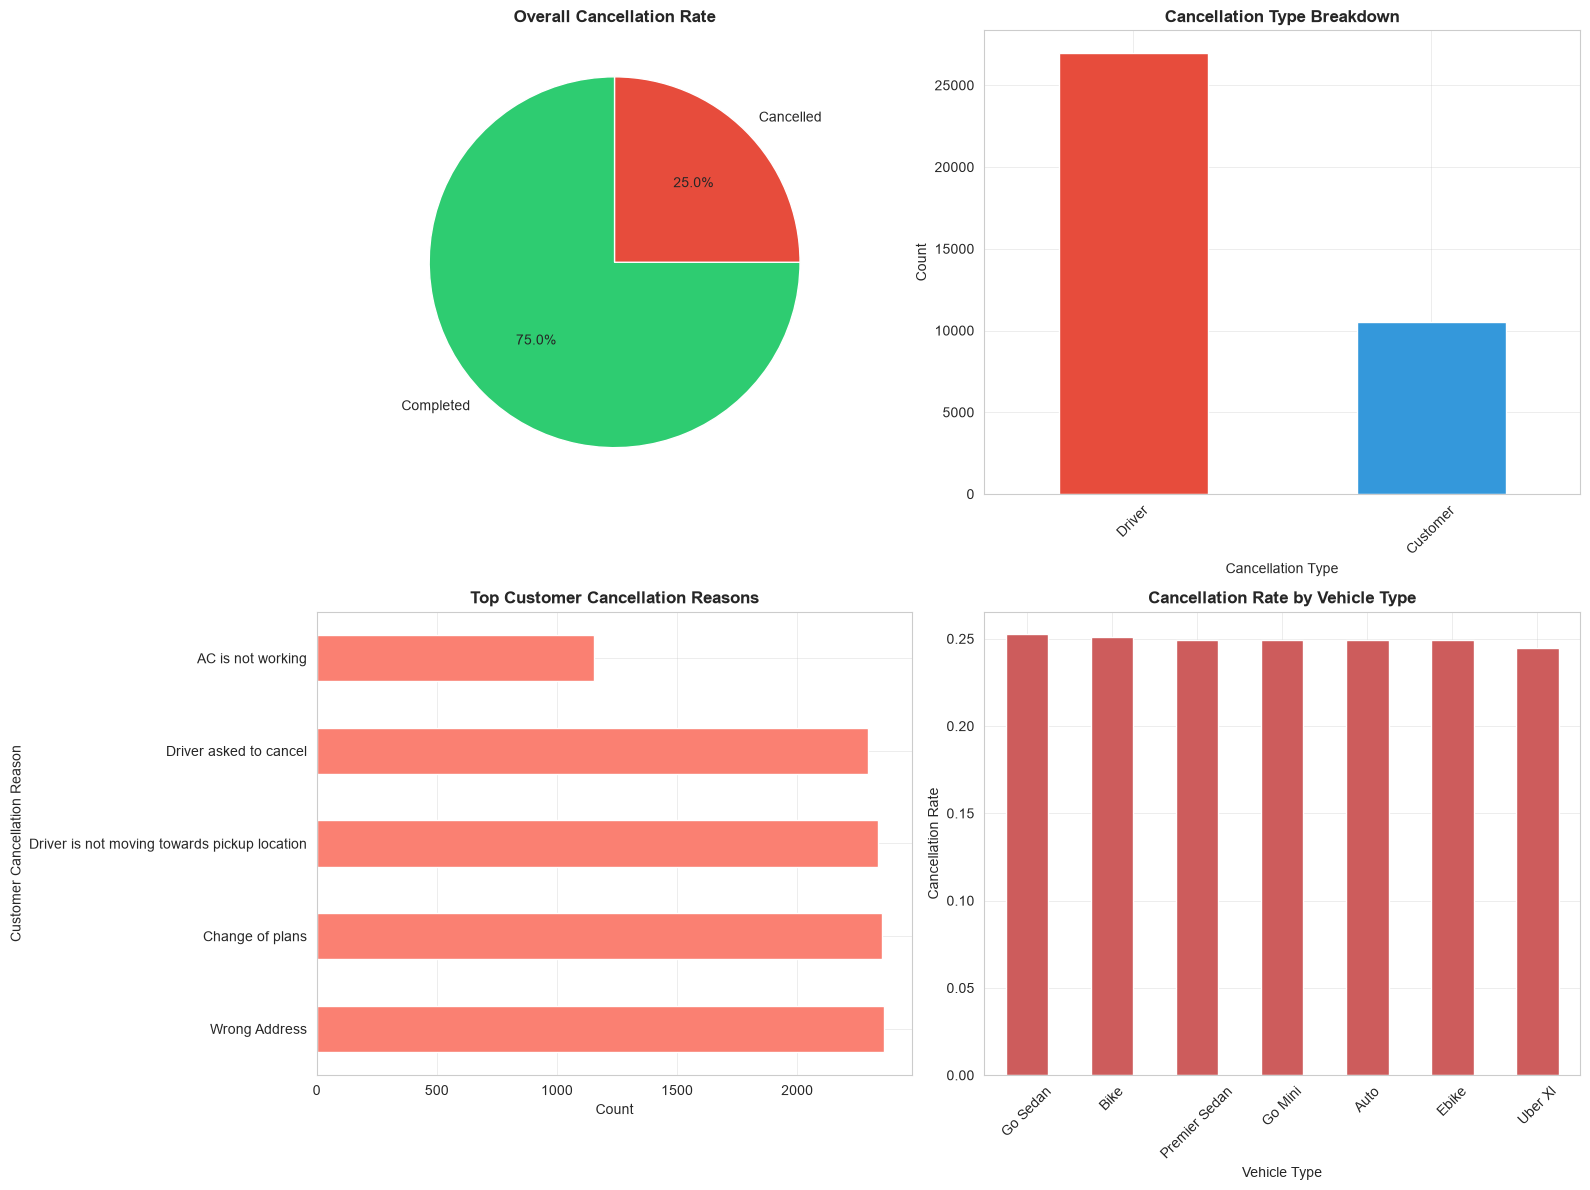

In [4]:
# ============================================================
# CELL 4: Cancellation Analysis
# ============================================================
plot_cancellation_analysis(df, save=True)

In [5]:
# Diagnostic: Check if cancellation columns were properly mapped
print("Columns in df:", list(df.columns))
print("\nCancellation-related columns:")
for col in df.columns:
    if 'cancel' in col.lower() or 'cancelled' in col.lower():
        print(f"  {col}: {df[col].dtype}")
        print(f"    Unique values: {df[col].unique()[:10]}")
        print(f"    Value counts:\n{df[col].value_counts()}")

Columns in df: ['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Customer Cancellation', 'Customer Cancellation Reason', 'Driver Cancellation', 'Driver Cancellation Reason', 'Incomplete Ride', 'Incomplete Ride Reason', 'Booking Value', 'Ride Distance', 'Driver Rating', 'Customer Rating', 'Payment Method', 'Booking_DateTime', 'Booking_Hour', 'Booking_Day', 'Booking_Month', 'Booking_Weekday', 'Is_Weekend', 'Time_of_Day', 'Is_Cancelled', 'Cancellation_Type', 'Revenue_per_km', 'High_Value_Ride', 'Wait_Time_Category', 'Distance_Category', 'Avg_Rating', 'Rating_Category']

Cancellation-related columns:
  Customer Cancellation: bool
    Unique values: [False  True]
    Value counts:
Customer Cancellation
False    139500
True      10500
Name: count, dtype: int64
  Customer Cancellation Reason: str
    Unique values: <ArrowStringArray>
[                               'Not Cancelled',
 'Driver is not movin

## Step 4: Revenue Analysis

Examine revenue by vehicle type, payment method, and fare distribution.

💾 Figure saved: ../outputs/figures\revenue_analysis.png


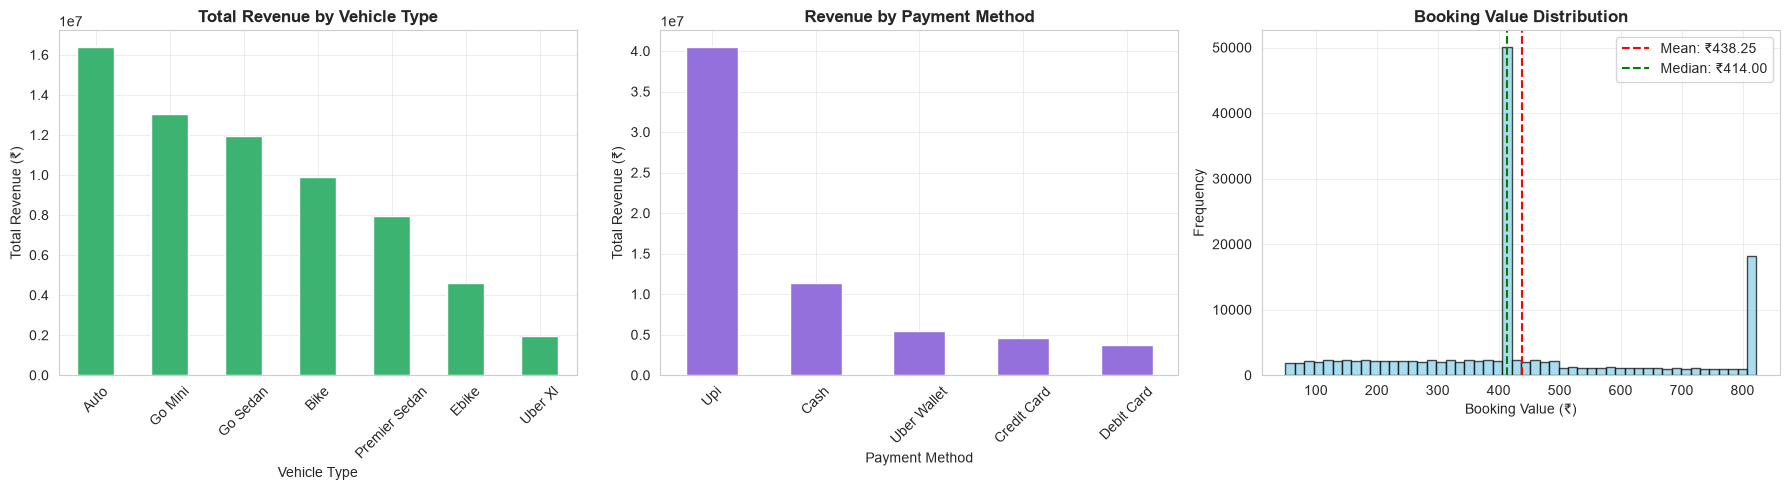

In [6]:
# ============================================================
# CELL 5: Revenue Analysis
# ============================================================
plot_revenue_analysis(df, save=True)

## Step 5: Rating & Satisfaction Analysis

Compare customer and driver ratings across vehicle types.

💾 Figure saved: ../outputs/figures\rating_analysis.png


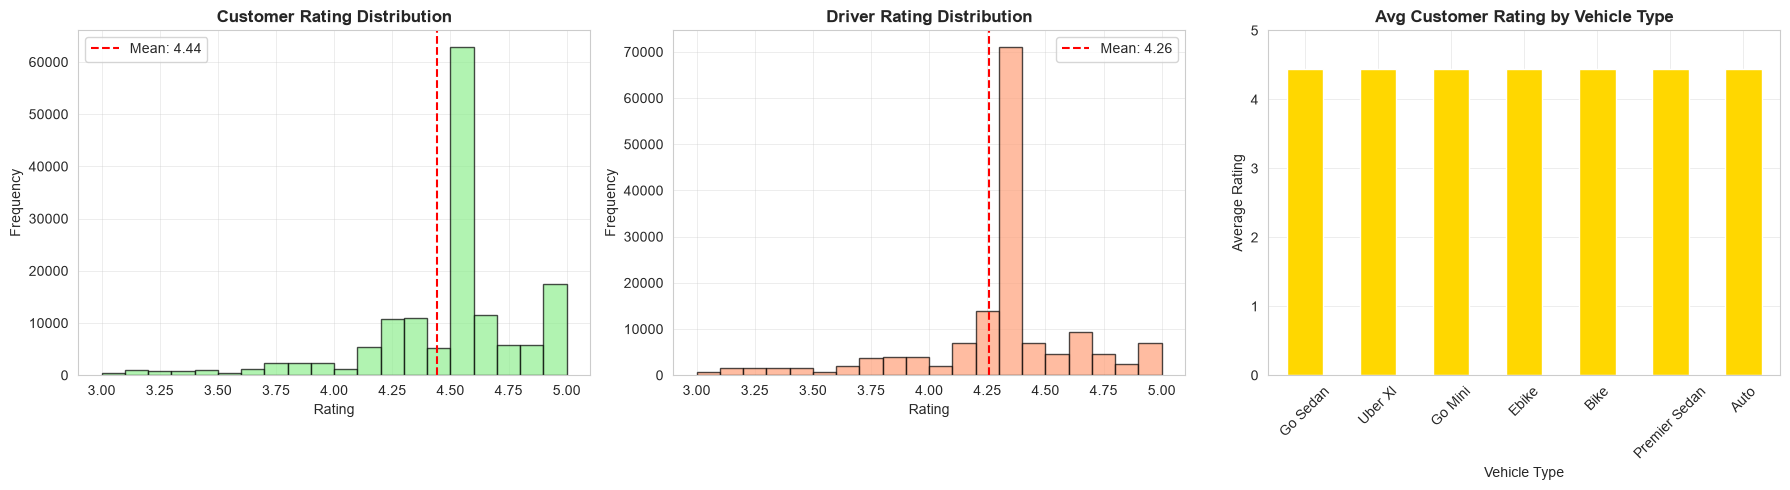

In [7]:
# ============================================================
# CELL 6: Rating Analysis
# ============================================================
plot_rating_analysis(df, save=True)

## Step 6: Operational Metrics

Analyse ride distance, trip duration (CTAT), and driver arrival time (VTAT).

💾 Figure saved: ../outputs/figures\operational_metrics.png


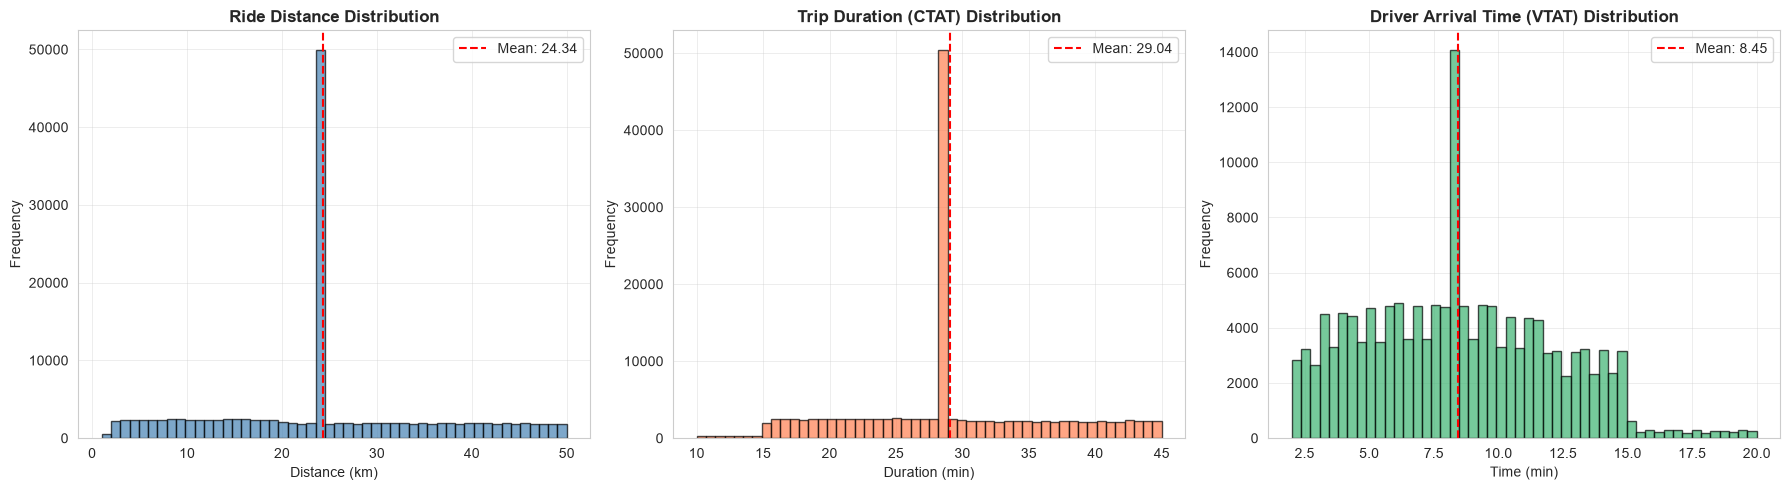

In [8]:
# ============================================================
# CELL 7: Operational Metrics
# ============================================================
plot_operational_metrics(df, save=True)

## Step 7: Key Insights Summary

Generate a text summary of key findings for quick reference during Review 1.

In [9]:
# ============================================================
# CELL 8: Key Insights
# ============================================================
print('🔍 KEY INSIGHTS FROM EDA')
print('=' * 60)

print(f'Total Bookings Analysed: {len(df):,}')

# Cancellation
if 'Is_Cancelled' in df.columns:
    cancel_rate = df['Is_Cancelled'].mean() * 100
    print(f'🚫 Overall Cancellation Rate: {cancel_rate:.2f}%')

# Top vehicle
if 'Vehicle Type' in df.columns:
    top_vehicle = df['Vehicle Type'].value_counts().index[0]
    top_vehicle_pct = df['Vehicle Type'].value_counts().iloc[0] / len(df) * 100
    print(f'🚗 Most Popular Vehicle: {top_vehicle} ({top_vehicle_pct:.1f}% of bookings)')

# Revenue
if 'Booking Value' in df.columns:
    total_revenue = df['Booking Value'].sum()
    print(f'💰 Total Revenue: ₹{total_revenue:,.2f}')
    print(f'💰 Average Fare: ₹{df["Booking Value"].mean():.2f}')

# Ratings
if 'Customer Rating' in df.columns:
    print(f'⭐ Avg Customer Rating: {df["Customer Rating"].mean():.2f}/5')
if 'Driver Rating' in df.columns:
    print(f'⭐ Avg Driver Rating: {df["Driver Rating"].mean():.2f}/5')

# Peak hour
if 'Booking_Hour' in df.columns:
    peak_hour = df['Booking_Hour'].value_counts().index[0]
    print(f'⏰ Peak Booking Hour: {peak_hour}:00')

# Top payment method
if 'Payment Method' in df.columns:
    top_payment = df['Payment Method'].value_counts().index[0]
    print(f'💳 Top Payment Method: {top_payment}')

print('\n✅ All figures saved to ../outputs/figures/')

🔍 KEY INSIGHTS FROM EDA
Total Bookings Analysed: 150,000
🚫 Overall Cancellation Rate: 25.00%
🚗 Most Popular Vehicle: Auto (24.9% of bookings)
💰 Total Revenue: ₹65,737,174.50
💰 Average Fare: ₹438.25
⭐ Avg Customer Rating: 4.44/5
⭐ Avg Driver Rating: 4.26/5
⏰ Peak Booking Hour: 18:00
💳 Top Payment Method: Upi

✅ All figures saved to ../outputs/figures/


---

## ✅ Notebook Complete!

**Generated outputs:**
- `outputs/figures/booking_trends.png`
- `outputs/figures/cancellation_analysis.png`
- `outputs/figures/revenue_analysis.png`
- `outputs/figures/rating_analysis.png`
- `outputs/figures/operational_metrics.png`

**Next:** Open `03_cancellation_analysis.ipynb` for a deeper dive into cancellation drivers.